<a href="https://colab.research.google.com/github/ananthika123/AI-ML-ICT-Academy/blob/main/caseStudyPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [2]:
# Load the dataset

df = pd.read_csv("/content/House_Pricing.csv")

# Display first 5 rows

df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [3]:
df.shape

(21613, 21)

In [4]:
# Display basic information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [5]:
# Statistical summary of numerical columns

df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [6]:
# Check missing values in each column

df.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [7]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [9]:
# Fill missing categorical values with mode

categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [10]:
df.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,0


In [11]:
# Convert date column into datetime

df["Date House was Sold"] = pd.to_datetime(
    df["Date House was Sold"],
    errors="coerce"
)

df["Date House was Sold"].head()

,Date House was Sold
0,2017-10-14
1,2017-12-14
2,2016-02-15
3,2017-12-14
4,2016-02-15


In [12]:
# Extract useful date information

df["Sale_Year"] = df["Date House was Sold"].dt.year
df["Sale_Month"] = df["Date House was Sold"].dt.month
df["Sale_Day"] = df["Date House was Sold"].dt.day

In [13]:
df.drop("Date House was Sold", axis=1, inplace=True)

In [14]:
df["Waterfront View"] = df["Waterfront View"].map({
    "Yes": 1,
    "No": 0
})

In [15]:
visit_mapping = {
    "Once": 1,
    "Twice": 2,
    "Thrice": 3,
    "Four": 4
}

df["No of Times Visited"] = df["No of Times Visited"].map(visit_mapping)

In [16]:
df["No of Times Visited"].unique()

array([2, 3, 4, 1])

In [17]:
condition_mapping = {
    "Bad": 1,
    "Fair": 2,
    "Okay": 3,
    "Good": 4,
    "Excellent": 5
}

df["Condition of the House"] = df["Condition of the House"].map(condition_mapping)

In [18]:
df.head()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year,Sale_Month,Sale_Day
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,0,2,2,...,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10,14
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,0,2,2,...,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12,14
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,0,2,2,...,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2,15
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,0,2,5,...,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12,14
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,0,2,2,...,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2,15


In [19]:
df.drop("ID", axis=1, inplace=True)

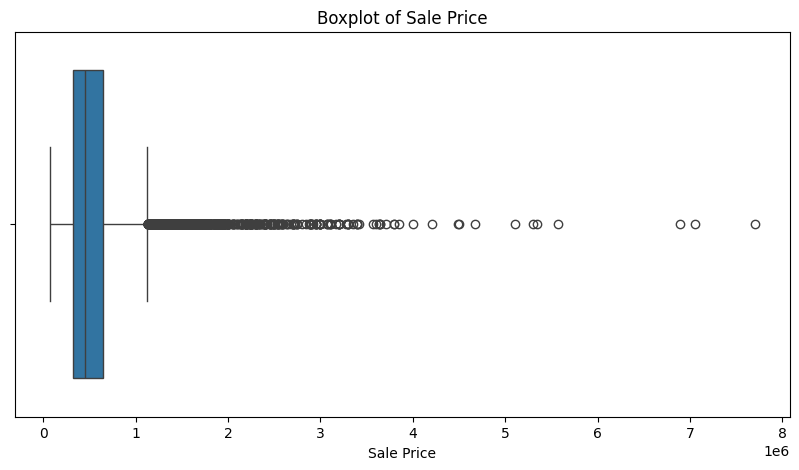

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Sale Price"])

plt.title("Boxplot of Sale Price")

plt.show()

In [21]:
# Select only numerical columns

numerical_df = df.select_dtypes(include=np.number)

print(numerical_df.columns)

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Waterfront View', 'No of Times Visited', 'Condition of the House',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)', 'Sale_Year', 'Sale_Month',
       'Sale_Day'],
      dtype='object')


In [22]:
# Calculate correlation matrix

correlation_matrix = numerical_df.corr()

correlation_matrix

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,...,Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year,Sale_Month,Sale_Day
Sale Price,1.000000,0.308366,0.525041,0.702024,0.089568,0.256836,0.266334,0.291690,0.014402,0.580644,...,-0.053988,0.126444,-0.053190,0.306850,0.021538,0.585377,0.082456,-0.003551,-0.010060,0.003551
No of Bedrooms,0.308366,1.000000,0.515866,0.576566,0.031668,0.175429,-0.006582,0.042646,0.010673,0.349008,...,-0.154178,0.018841,-0.152651,-0.008885,0.129494,0.391651,0.029244,0.009838,-0.001533,-0.009838
No of Bathrooms,0.525041,0.515866,1.000000,0.754565,0.087717,0.500575,0.063751,0.123571,-0.164893,0.635541,...,-0.505928,0.050745,-0.203965,0.024495,0.223125,0.568542,0.087213,0.026439,0.007176,-0.026439
Flat Area (in Sqft),0.702024,0.576566,0.754565,1.000000,0.172723,0.353875,0.103837,0.182835,-0.085705,0.705666,...,-0.318063,0.055380,-0.199397,0.052518,0.240111,0.756188,0.183228,0.029132,0.011917,-0.029132
Lot Area (in Sqft),0.089568,0.031668,0.087717,0.172723,1.000000,-0.005218,0.021609,0.054333,0.002656,0.102316,...,-0.053069,0.007643,-0.129537,-0.085707,0.229466,0.144516,0.718531,-0.005516,-0.002370,0.005516
No of Floors,0.256836,0.175429,0.500575,0.353875,-0.005218,1.000000,0.023698,0.038366,-0.302492,0.461228,...,-0.489319,0.006338,-0.059122,0.049644,0.125394,0.279858,-0.011269,0.022315,0.014005,-0.022315
Waterfront View,0.266334,-0.006582,0.063751,0.103837,0.021609,0.023698,1.000000,0.485043,0.017135,0.070333,...,0.026161,0.092885,0.030289,-0.014271,-0.041913,0.086466,0.030703,0.004165,0.008132,-0.004165
No of Times Visited,0.291690,0.042646,0.123571,0.182835,0.054333,0.038366,0.485043,1.000000,0.021553,0.140246,...,0.011442,0.074188,0.034430,-0.003071,-0.024267,0.167658,0.055685,0.004945,0.000539,-0.004945
Condition of the House,0.014402,0.010673,-0.164893,-0.085705,0.002656,-0.302492,0.017135,0.021553,1.000000,-0.180338,...,0.394334,-0.067485,-0.004042,-0.029381,-0.111345,-0.109926,0.005359,0.038827,0.017291,-0.038827
Overall Grade,0.580644,0.349008,0.635541,0.705666,0.102316,0.461228,0.070333,0.140246,-0.180338,1.000000,...,-0.456629,0.010440,-0.185839,0.111298,0.201746,0.681332,0.107581,0.030953,0.007640,-0.030953


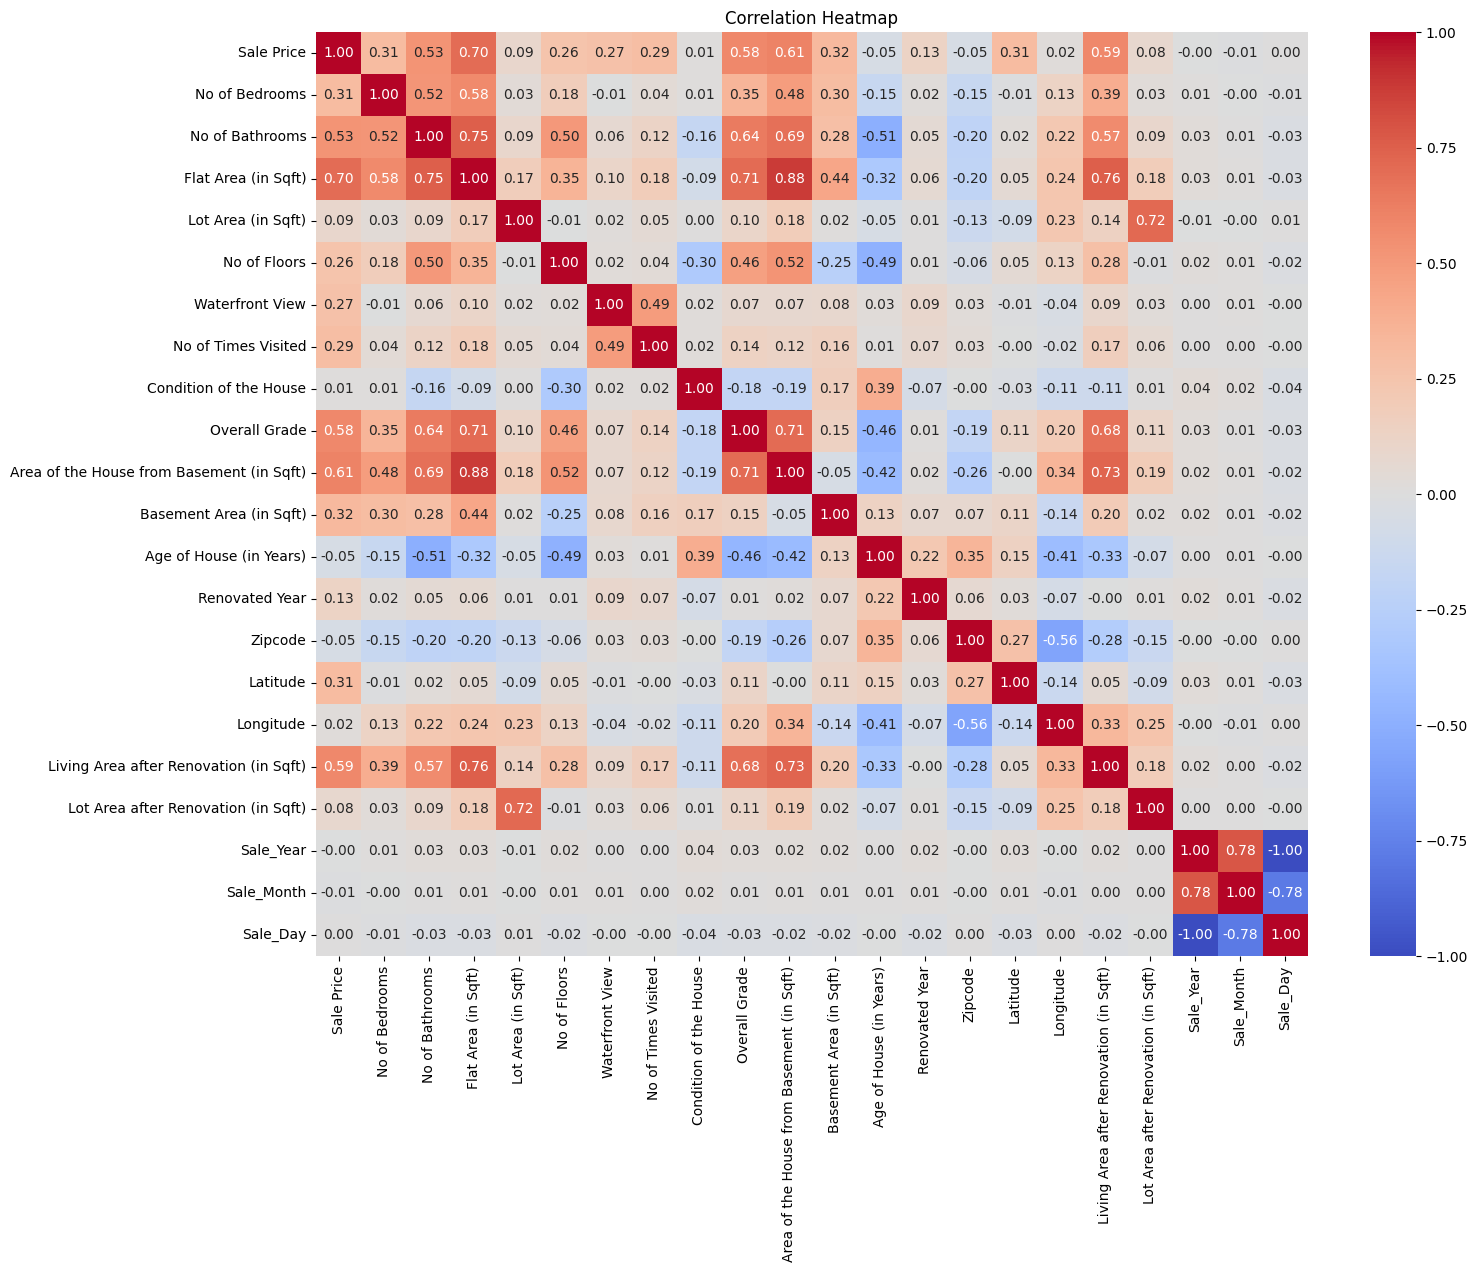

In [23]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [24]:
# Correlation of all features with Sale Price

target_correlation = correlation_matrix["Sale Price"].sort_values(
    ascending=False
)

print(target_correlation)

Sale Price                                   1.000000
Flat Area (in Sqft)                          0.702024
Area of the House from Basement (in Sqft)    0.605344
Living Area after Renovation (in Sqft)       0.585377
Overall Grade                                0.580644
No of Bathrooms                              0.525041
Basement Area (in Sqft)                      0.323781
No of Bedrooms                               0.308366
Latitude                                     0.306850
No of Times Visited                          0.291690
Waterfront View                              0.266334
No of Floors                                 0.256836
Renovated Year                               0.126444
Lot Area (in Sqft)                           0.089568
Lot Area after Renovation (in Sqft)          0.082456
Longitude                                    0.021538
Condition of the House                       0.014402
Sale_Day                                     0.003551
Sale_Year                   

In [25]:
# Select features having correlation greater than 0.10
# or less than -0.10 with Sale Price

selected_features = target_correlation[
    target_correlation.abs() >= 0.10
].index

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Sale Price', 'Flat Area (in Sqft)',
       'Area of the House from Basement (in Sqft)',
       'Living Area after Renovation (in Sqft)', 'Overall Grade',
       'No of Bathrooms', 'Basement Area (in Sqft)', 'No of Bedrooms',
       'Latitude', 'No of Times Visited', 'Waterfront View', 'No of Floors',
       'Renovated Year'],
      dtype='object')


In [26]:
selected_features = selected_features.drop("Sale Price")

print("Final Selected Features:")
print(selected_features)

Final Selected Features:
Index(['Flat Area (in Sqft)', 'Area of the House from Basement (in Sqft)',
       'Living Area after Renovation (in Sqft)', 'Overall Grade',
       'No of Bathrooms', 'Basement Area (in Sqft)', 'No of Bedrooms',
       'Latitude', 'No of Times Visited', 'Waterfront View', 'No of Floors',
       'Renovated Year'],
      dtype='object')


In [27]:
# Create X using selected features

X = df[selected_features]

# Target

y = df["Sale Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21613, 12)
y shape: (21613,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (17290, 12)
Testing data: (4323, 12)


In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [31]:
y_pred_lr = lr_model.predict(X_test_scaled)

print(y_pred_lr[:10])

[ 437961.62594752  783574.75872674 1037070.23506059 1364851.05633418
  770904.37189229  270553.4576449   770830.60728747  531210.5674274
  397476.50506754  326229.00243515]


In [32]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("-------------------------")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
-------------------------
MAE : 143213.81723100858
MSE : 54927678639.58987
RMSE: 234366.54761204694
R2 Score: 0.6370478628544525


In [33]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [34]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [35]:
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regressor")
print("----------------------")
print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

KNN Regressor
----------------------
MAE : 107500.95623409668
MSE : 42949458417.85855
RMSE: 207242.51112611656
R2 Score: 0.7161977693561239


In [36]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=100,
    gamma="scale"
)

svr_model.fit(X_train_scaled, y_train)

SVR(C=100)

In [37]:
y_pred_svr = svr_model.predict(X_test_scaled)

In [38]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR")
print("----------------------")
print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)

SVR
----------------------
MAE : 184132.99535208265
MSE : 133936133971.97557
RMSE: 365972.85961116786
R2 Score: 0.11497432132325991


In [39]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [40]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("-------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regressor
-------------------------
MAE : 92165.46014168646
MSE : 31783989755.714195
RMSE: 178280.64885375023
R2 Score: 0.7899771609766542


In [41]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regressor",
        "SVR",
        "Random Forest Regressor"
    ],

    "MAE": [
        mae_lr,
        mae_knn,
        mae_svr,
        mae_rf
    ],

    "MSE": [
        mse_lr,
        mse_knn,
        mse_svr,
        mse_rf
    ],

    "RMSE": [
        rmse_lr,
        rmse_knn,
        rmse_svr,
        rmse_rf
    ],

    "R2 Score": [
        r2_lr,
        r2_knn,
        r2_svr,
        r2_rf
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,143213.817231,5.492768e+10,234366.547612,0.637048
1,KNN Regressor,107500.956234,4.294946e+10,207242.511126,0.716198
2,SVR,184132.995352,1.339361e+11,365972.859611,0.114974
3,Random Forest Regressor,92165.460142,3.178399e+10,178280.648854,0.789977


In [42]:

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
3,Random Forest Regressor,92165.460142,3.178399e+10,178280.648854,0.789977
1,KNN Regressor,107500.956234,4.294946e+10,207242.511126,0.716198
0,Linear Regression,143213.817231,5.492768e+10,234366.547612,0.637048
2,SVR,184132.995352,1.339361e+11,365972.859611,0.114974
